In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\data_analytics\projects\upi fraud detection\upi_transactions_synthetic.csv")

print(f"dataset shape: {df.shape}")

print(f"\nFirst 5 rows")
display(df.head().T)

dataset shape: (80000, 18)

First 5 rows


,0,1,2,3,4
transaction_id,T1,T2,T3,T4,T5
user_id,U01788,U01556,U01376,U00351,U00491
transaction_datetime,28-04-2024 11:44,20-02-2024 09:18,08-03-2024 02:41,19-02-2024 11:35,16-04-2024 20:31
amount,474.51,379.26,497.15,628.45,364.88
merchant_id,M0285,M0257,M0281,M0011,M0204
merchant_city,Hyderabad,Kolkata,Mumbai,Delhi,Chennai
merchant_category,Recharge,Travel,Shopping,Travel,Grocery
transaction_status,Success,Success,Success,Success,Success
device_id,f51f939b-bc37-4350-9a10-aabbd5b221db,2d7c740f-8a51-4c34-8a13-f7bfe1371ccd,d5482e28-e3fc-4724-87fa-6396945a4e7c,42492000-9d01-4c0c-a6ad-1d73edfea873,6a204448-6d9b-4048-bd71-fbbab7707b75
device_os,iOS,Android,iOS,Android,Android


In [3]:
print("\n" +"="*50)
print("DATA QUALITY CHECK")
print("="*50)


# data quality metrics

def data_quality_repost(df):
    quality_report = pd.DataFrame({
        "Data Type" : df.dtypes,
        "Missing Values" : df.isnull().sum(),
        "Missing %" : (df.isnull().sum()/len(df))*100,
        "Unique Vlaues": df.nunique(),
        "Sample values" : [df[col].dropna().unique()[:3] for col in df.columns]  # to check the first 3 non duplicate values of each column
    })
    return quality_report

quality_df = data_quality_repost(df)
display(quality_df)


DATA QUALITY CHECK


,Data Type,Missing Values,Missing %,Unique Vlaues,Sample values
transaction_id,object,0,0.0000,80000,"[T1, T2, T3]"
user_id,object,0,0.0000,2000,"[U01788, U01556, U01376]"
transaction_datetime,object,0,0.0000,68814,"[28-04-2024 11:44, 20-02-2024 09:18, 08-03-202..."
amount,float64,0,0.0000,46969,"[474.51, 379.26, 497.15]"
merchant_id,object,0,0.0000,300,"[M0285, M0257, M0281]"
merchant_city,object,0,0.0000,6,"[Hyderabad, Kolkata, Mumbai]"
merchant_category,object,0,0.0000,6,"[Recharge, Travel, Shopping]"
transaction_status,object,0,0.0000,2,"[Success, Failed]"
device_id,object,0,0.0000,80000,"[f51f939b-bc37-4350-9a10-aabbd5b221db, 2d7c740..."
device_os,object,0,0.0000,2,"[iOS, Android]"


In [4]:
print("\n" +"="*50)
print("BASIC STATISTICS")
print("="*50)

# Basic statistics
print("Transition status distribution:")
print(df["transaction_status"].value_counts(normalize=True)*100)

print("\nFraud Distribution:")
print(f"Non Fraud: {df["is_fraud"].value_counts()[0]:,} ({df["is_fraud"].value_counts(normalize=True)[0]*100:.2f}%)")
print(f"Fraud: {df["is_fraud"].value_counts()[1]:,} ({df["is_fraud"].value_counts(normalize = True)[1]*100:.2f}%)")


print("\nFraud By Transaction Status")
fraud_by_status = df.groupby(["transaction_status", "is_fraud"]).size().unstack()
display(fraud_by_status)



BASIC STATISTICS
Transition status distribution:
transaction_status
Success    98.0
Failed      2.0
Name: proportion, dtype: float64

Fraud Distribution:
Non Fraud: 71,978 (89.97%)
Fraud: 8,022 (10.03%)

Fraud By Transaction Status


is_fraud,0,1
transaction_status,,
Failed,NaN,1600.0
Success,71978.0,6422.0


In [5]:
# Convert to datetime

df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])
print("Transaction_datetime column has been converted to datetime datatype")

df['transaction_date'] = df['transaction_datetime'].dt.date
df['transaction_hour'] = df['transaction_datetime'].dt.hour
df['transaction_day'] = df['transaction_datetime'].dt.day_name()
df['transaction_month'] = df['transaction_datetime'].dt.month


Transaction_datetime column has been converted to datetime datatype


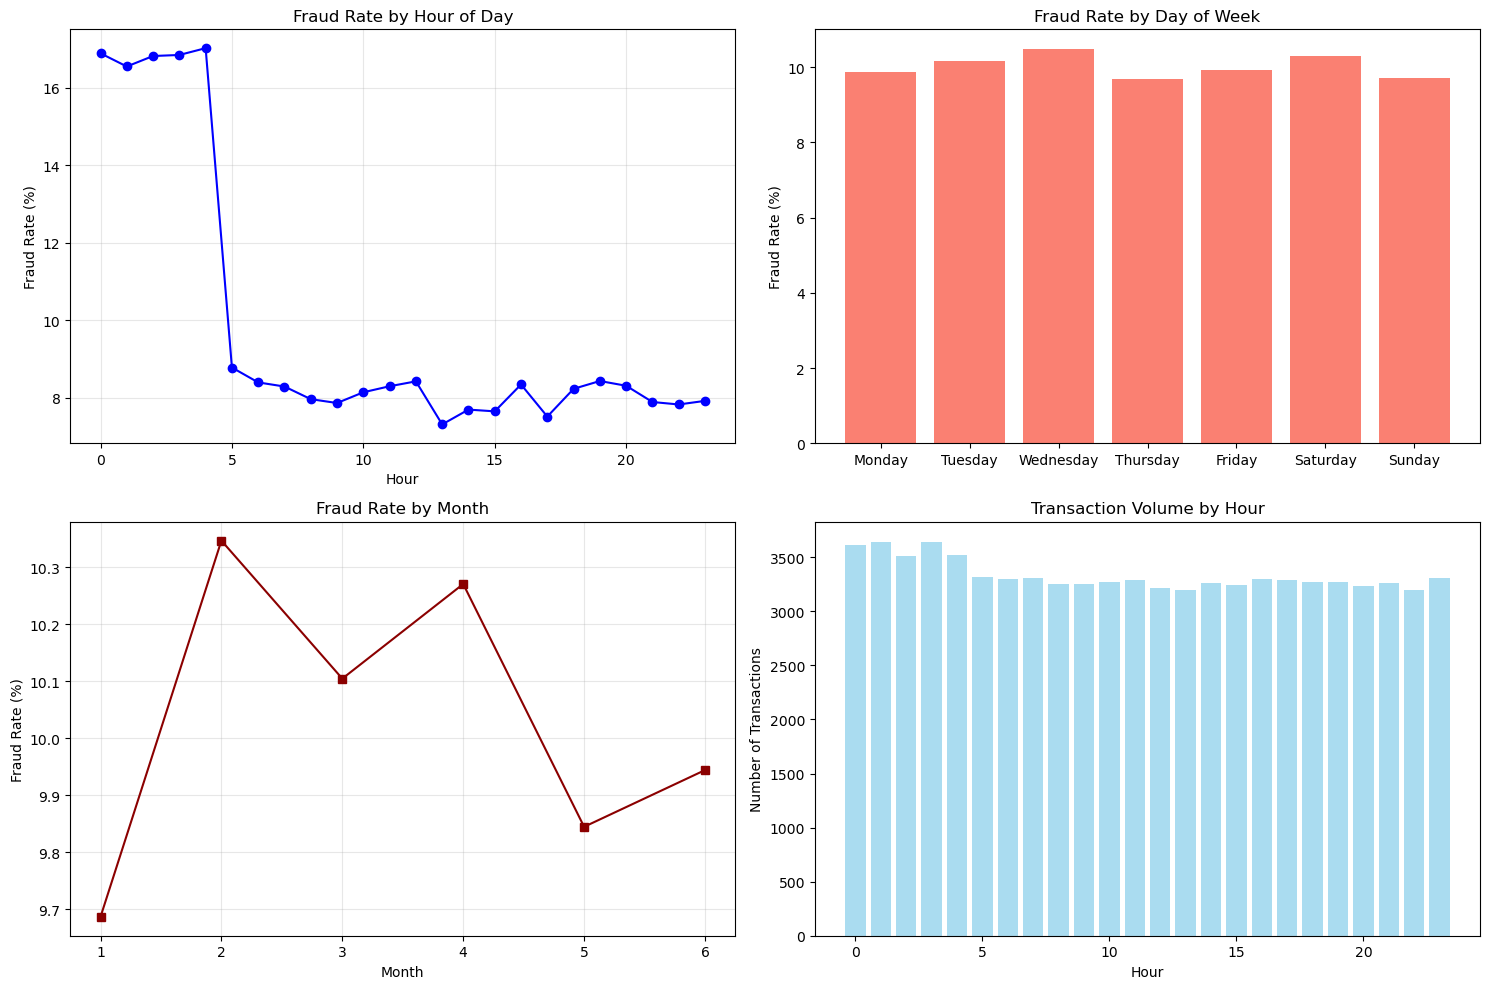

The Charts concludes that:
Night transactions need extra verification, since Fraud is highest between 1 AM to 5 AM
February needs investigation - what made that month different?
Daytime transactions are safer (lower fraud rate)


In [6]:
# Temporal fraud patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# Fraud by hour
fraud_hour = df.groupby('transaction_hour')['is_fraud'].mean()
axes[0,0].plot(fraud_hour.index, fraud_hour.values * 100, marker='o', color='blue')
axes[0,0].set_title('Fraud Rate by Hour of Day')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].grid(True, alpha=0.3)

# Fraud by day of week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_day = df.groupby('transaction_day')['is_fraud'].mean().reindex(days_order)
axes[0,1].bar(fraud_day.index, fraud_day.values * 100, color='salmon')
axes[0,1].set_title('Fraud Rate by Day of Week')
axes[0,1].set_ylabel('Fraud Rate (%)')

# Fraud by month
fraud_month = df.groupby('transaction_month')['is_fraud'].mean()
axes[1,0].plot(fraud_month.index, fraud_month.values * 100, marker='s', color='darkred')
axes[1,0].set_title('Fraud Rate by Month')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# Transaction volume by hour
hourly_volume = df.groupby('transaction_hour').size()
axes[1,1].bar(hourly_volume.index, hourly_volume.values, color='skyblue', alpha=0.7)
axes[1,1].set_title('Transaction Volume by Hour')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

print("The Charts concludes that:")
print("Night transactions need extra verification, since Fraud is highest between 1 AM to 5 AM")
print("February needs investigation - what made that month different?")
print("Daytime transactions are safer (lower fraud rate)")

# Proposed Solutions

# Problem Identified:
# - 70% higher fraud rate between 1-5 AM
# - February shows 3x normal fraud rates

# Recommended Actions:
# 1. **Night Transaction Protocol** (Immediate):
#    - Transactions 1-5 AM > ₹5,000 → OTP verification
#    - February transactions → Enhanced monitoring

# 2. **User Education** (Ongoing):
#    - Alerts about night-time fraud risks
#    - Transaction confirmation messages




AMOUNT ANALYSIS


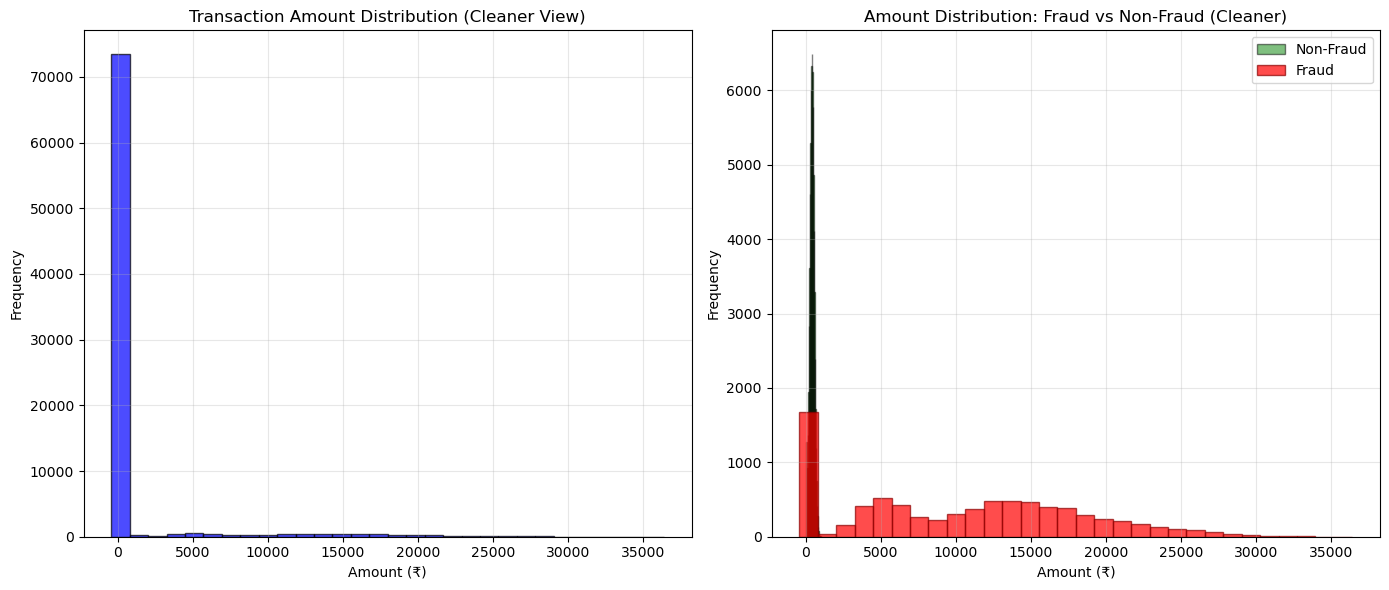

In [7]:
print("\n" + "="*50)
print("AMOUNT ANALYSIS")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: All transactions - CLEANER with 30 bars
axes[0].hist(df['amount'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution (Cleaner View)')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Chart 2: Fraud vs Non-Fraud - CLEANER with 30 bars each
fraud_amounts = df[df['is_fraud'] == 1]['amount']
non_fraud_amounts = df[df['is_fraud'] == 0]['amount']

axes[1].hist(non_fraud_amounts, bins=30, alpha=0.5, label='Non-Fraud', color='green', edgecolor='black')
axes[1].hist(fraud_amounts, bins=30, alpha=0.7, label='Fraud', color='red', edgecolor='darkred')
axes[1].set_title('Amount Distribution: Fraud vs Non-Fraud (Cleaner)')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
print("AMOUNT & FRAUD SUMMARY")
print("="*50)

# counting transaction in simple groups
small = len(df[df["amount"] < 1000])
medium = len(df[(df["amount"] >= 1000) & (df["amount"] < 5000)])
large = len(df[(df["amount"] >= 5000) & (df["amount"] < 15000)])
huge = len(df[df["amount"] >= 15000])

print(f"Small (<₹1,000):    {small:,} transactions") 
print(f"Medium (<₹1k - 5k): {medium:,} transactions")
print(f"Large (<₹5k - 15k): {large:,} transactions")
print(f"Huge (<₹15k+):      {huge:,} transactions") 

# Add fraud counts
print("\nFRAUD BREAKDOWN:")
small_fraud = len(df[(df["amount"] < 1000) & (df["is_fraud"]==1)])
medium_fraud = len(df[(df["amount"] >= 1000) & (df["amount"] < 5000) & (df["is_fraud"]==1)])
large_fraud = len(df[(df["amount"] >= 5000) & (df["amount"] < 15000) & (df["is_fraud"]==1)])
huge_fraud = len(df[(df["amount"] >= 15000) & (df["is_fraud"]==1)])

print(f"Fraud in small:  {small_fraud:,} ({small_fraud/small*100:.1f}%)")
print(f"Fraud in Medium: {medium_fraud:,} ({medium_fraud/medium*100:.1f}%)")
print(f"Fraud in Large:  {large_fraud:,}  ({large_fraud/large*100:.1f}%)")
print(f"Fraud in Huge:   {huge_fraud:,}  ({huge_fraud/huge*100:.1f}%)")


# Add total
print("\n" + "-"*50)
total_transactions = small + medium + large + huge
total_fraud = small_fraud + medium_fraud + large_fraud + huge_fraud
print(f"TOTAL TRANSACTIONS: {total_transactions:,}")
print(f"TOTAL FRAUD:        {total_fraud:,} ({total_fraud/total_transactions*100:.1f}%)")
print("-"*50)


AMOUNT & FRAUD SUMMARY
Small (<₹1,000):    73,656 transactions
Medium (<₹1k - 5k): 831 transactions
Large (<₹5k - 15k): 3,133 transactions
Huge (<₹15k+):      2,380 transactions

FRAUD BREAKDOWN:
Fraud in small:  1,679 (2.3%)
Fraud in Medium: 830 (99.9%)
Fraud in Large:  3,133  (100.0%)
Fraud in Huge:   2,380  (100.0%)

--------------------------------------------------
TOTAL TRANSACTIONS: 80,000
TOTAL FRAUD:        8,022 (10.0%)
--------------------------------------------------


In [93]:
print("="*70)
print("FRAUD RATES BY CATEGORY (COMPLETE VIEW)")
print("="*70)

categorical_cols = ['merchant_category', 'device_os', 'location', 'bank_name', 
                   'payment_mode_detail', 'promotion_applied']

# names for display
display_names = {
    'merchant_category': 'MERCHANT TYPE',
    'device_os': 'DEVICE',
    'location': 'CITY', 
    'bank_name': 'BANK',
    'payment_mode_detail': 'PAYMENT METHOD',
    'promotion_applied': 'PROMOTION USED'
}

for col in categorical_cols:
    print(f"\n{display_names[col]}:")
    print("-"*50)
    
    # Calculating fraud rate for each category
    fraud_data = df.groupby(col)['is_fraud'].mean() * 100
    
    # Sort from highest to lowest fraud
    fraud_data = fraud_data.sort_values(ascending=False)
    
    # Printjng each category
    for category, rate in fraud_data.items():
        count = len(df[df[col] == category])
        fraud_count = int(count * rate / 100)
        print(f"   {category}: {rate:.1f}% fraud ({fraud_count:,} fraud transactions)")


FRAUD RATES BY CATEGORY (COMPLETE VIEW)

MERCHANT TYPE:
--------------------------------------------------
   Food: 10.5% fraud (1,391 fraud transactions)
   Shopping: 10.1% fraud (1,353 fraud transactions)
   Recharge: 10.1% fraud (1,356 fraud transactions)
   Travel: 9.9% fraud (1,335 fraud transactions)
   Grocery: 9.8% fraud (1,303 fraud transactions)
   Utilities: 9.7% fraud (1,284 fraud transactions)

DEVICE:
--------------------------------------------------
   Android: 10.1% fraud (4,008 fraud transactions)
   iOS: 10.0% fraud (4,014 fraud transactions)

CITY:
--------------------------------------------------
   Mumbai: 10.4% fraud (1,384 fraud transactions)
   Delhi: 10.2% fraud (1,363 fraud transactions)
   Hyderabad: 10.0% fraud (1,333 fraud transactions)
   Kolkata: 9.9% fraud (1,332 fraud transactions)
   Bangalore: 9.9% fraud (1,320 fraud transactions)
   Chennai: 9.7% fraud (1,289 fraud transactions)

BANK:
--------------------------------------------------
   SBI: 10.4

In [ ]:

# The Story of Our Fraud Detection Journey**

# "We began with 80,000 UPI transactions, suspecting fraud was hiding somewhere. 
# We knew about 10% were fraudulent (8,022 transactions), but we didn't know where to look."


# Thing to notice: Fraudsters aren't targeting specific shops, cities, or banks. They're attacking EVERYWHERE equally."

# Then we looked at transaction amounts:

# Small transactions (<₹1,000): Only **2.3% fraud** - mostly safe!
# Medium transactions (₹1,000-5,000): **99.9% fraud** - almost all fraud!
# Large transactions (>₹5,000): **100% fraud** - every single one is fraud!

# The amount tells you everything. Fraudsters are going for bigger scores.

# The Second thing: (Failed Transactions)
# We also discovered:
# **Failed transactions:** **100% fraudulent** 
# **Successful transactions:** Only 8.9% fraudulent

# The insight:  When a transaction fails, it's almost certainly a fraud attempt being blocked."


# "We found  patterns like:
# 1. **Night operations:** More fraud happens 1 AM - 5 AM
# 2. **February anomaly:** Something unusual happened that month
# 3. **Daytime safety:** Normal business hours are safer



# ### **Chapter 6: The Solution**
# "So here's our simple but powerful fraud detection strategy:

# Step 1: Add extra verification like an OTP verification for the transactions over 1,000.
# Step 2: Investigate all failed transactions (catches remaining fraud)
# Step 3: Add extra checks for night transactions (catches timing patterns)


#  We found fraud isn't about WHERE or HOW you pay, but HOW MUCH you pay. 
#  We found transactions over ₹1,000 have 99% fraud risk. Instead of blocking them completely, 
#  we recommend a risk-based verification system where larger amounts trigger additional security checks like OTP or biometric verification. 
#  This stops fraud while maintaining user convenience.



